# Базовый блок. Архитектура автокодировщика (Autoencoder). ДЗ Pro

## Задание Pro

1. Выберите 10 самых красивых по вашему мнению пятёрок в тренировочной выборке mnist.
2. Создайте датасет, где объекты — это все пятёрки из тренировочной части mnist, а метки — это случайные пятёрки из «красивого» набора.
3. Создайте автокодировщик и проверьте, совпадают ли у него размеры выхода и входа.
4. Обучите автокодировщик.
5. Добейтесь ошибки MSE на тренировочной выборке < 0.05.
6. Посмотрите, как выглядят пятёрки из тестовой выборки после обученного автокодировщика.

## Импорт библиотек

In [ ]:
# Для операций с тензорами
import numpy as np

# Для отрисовки
import matplotlib.pyplot as plt

# Для создания модели
from tensorflow.keras.models import Model

# Необходимые слои
from tensorflow.keras.layers import Input, Conv2DTranspose, MaxPooling2D, Conv2D, BatchNormalization

# Слои для латентного пространства модели
from tensorflow.keras.layers import Flatten, Reshape, Dense

# Оптимизатор
from tensorflow.keras.optimizers import Adam

# Для загрузки базы
from tensorflow.keras.datasets import mnist

%matplotlib inline

## Загрузка данных

In [ ]:
# Загрузка датасета
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
# Нормализация данных
X_train = X_train.astype('float32')/255.
X_test = X_test.astype('float32')/255.

In [ ]:
# Приведение формы к удобной для Keras
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [ ]:
# Отбор пятёрок
mask = y_train == 5
X_train = X_train[mask]
y_train = y_train[mask]

In [ ]:
# Аналогично для тестирования
mask = y_test == 5
X_test = X_test[mask]
y_test = y_test[mask]

## Отбор красивых пятёрок

Размер набора красивых пятёрок: (10, 28, 28, 1)


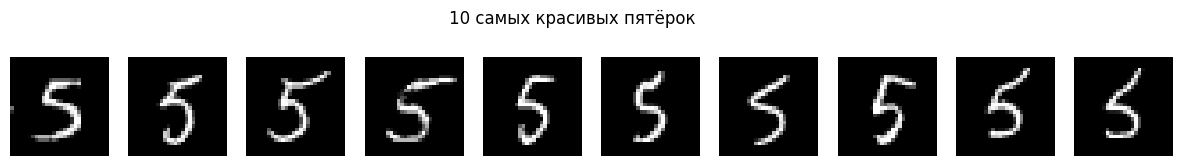

In [ ]:
# 1. Отбираем 10  пятёрок.
# Критерий: пятёрка близка к среднему образу пятёрки,
# то есть это наиболее каноничные, типичные представители класса.
# Используем расстояние до усреднённой пятёрки и берём 10 ближайших.

mean_five = X_train.mean(axis=0)                           # «эталонная» пятёрка
dist = np.sqrt(((X_train - mean_five) ** 2).reshape(len(X_train), -1).sum(axis=1))
beautiful_idx = np.argsort(dist)[:10]                      # 10 ближайших к эталону

beautiful = X_train[beautiful_idx]
print('Размер набора красивых пятёрок:', beautiful.shape)

# Визуализация
plt.figure(figsize=(15, 2))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(beautiful[i].squeeze(), cmap='gray')
    plt.axis('off')
plt.suptitle('10 самых красивых пятёрок')
plt.show()

## Создание датасета: объекты — все пятёрки, метки — случайные красивые

In [ ]:
# 2. Для каждой пятёрки из тренировочной выборки случайно выбираем
# одну из 10 красивых в качестве целевого образа.
np.random.seed(42)
random_targets_idx = np.random.randint(0, 10, size=len(X_train))
y_target = beautiful[random_targets_idx]                   # метки — красивые пятёрки

print('X_train:', X_train.shape)
print('y_target:', y_target.shape)

X_train: (5421, 28, 28, 1)
y_target: (5421, 28, 28, 1)


## Создание автокодировщика

In [ ]:
# 3. Архитектура автокодировщика.
# Размерность латентного пространства возьмём побольше (например, 32) —
# в задании Pro нет ограничения 2D, важна только ошибка < 0.05.

# Энкодер
encoder_input = Input(shape=(28, 28, 1))
x = Conv2D(32, (3, 3), padding='same', activation='relu')(encoder_input)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2), padding='same')(x)                # 14 x 14

x = Conv2D(64, (3, 3), padding='same', activation='relu')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2), padding='same')(x)                # 7 x 7

x = Conv2D(128, (3, 3), padding='same', activation='relu')(x)
x = BatchNormalization()(x)

x = Flatten()(x)
latent = Dense(32, activation='relu', name='latent_space')(x)

encoder = Model(encoder_input, latent, name='encoder')

# Декодер
decoder_input = Input(shape=(32,))
x = Dense(7 * 7 * 128, activation='relu')(decoder_input)
x = Reshape((7, 7, 128))(x)

x = Conv2DTranspose(64, (3, 3), strides=2, padding='same', activation='relu')(x)   # 14 x 14
x = BatchNormalization()(x)

x = Conv2DTranspose(32, (3, 3), strides=2, padding='same', activation='relu')(x)   # 28 x 28
x = BatchNormalization()(x)

decoder_output = Conv2D(1, (3, 3), padding='same', activation='sigmoid')(x)
decoder = Model(decoder_input, decoder_output, name='decoder')

# Автокодировщик
autoencoder = Model(encoder_input, decoder(encoder(encoder_input)), name='autoencoder')
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 32)             │       294,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 28, 28, 1)      │       299,905 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 594,209 (2.27 MB)

 Trainable params: 593,569 (2.26 MB)

 Non-trainable params: 640 (2.50 KB)

In [ ]:
# Проверка совпадения размеров входа и выхода
print('Вход :', autoencoder.input_shape)
print('Выход:', autoencoder.output_shape)
assert autoencoder.input_shape == autoencoder.output_shape, 'Размеры не совпадают!'
print('Размеры совпадают ✓')

Вход : (None, 28, 28, 1)
Выход: (None, 28, 28, 1)
Размеры совпадают ✓


## Обучение

In [ ]:
# 4. Компилируем и обучаем.
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

history = autoencoder.fit(
    X_train, y_target,           # вход — все пятёрки, выход — случайные красивые
    epochs=20,
    batch_size=128,
    shuffle=True,
    verbose=1
)

Epoch 1/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 14s 119ms/step - loss: 0.0811
Epoch 2/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0344
Epoch 3/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0332
Epoch 4/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0326
Epoch 5/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0324
Epoch 6/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0323
Epoch 7/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0323
Epoch 8/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0323
Epoch 9/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0323
Epoch 10/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0322
Epoch 11/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0322
Epoch 12/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0321
Epoch 13/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0321
Epoch 14/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0320
Epoch 15/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0318
Ep

In [ ]:
# 5. Проверяем итоговую MSE
final_loss = history.history['loss'][-1]
print(f'Финальная MSE на тренировочной выборке: {final_loss:.5f}')
print(f'Цель < 0.05: {"ДОСТИГНУТА" if final_loss < 0.05 else "НЕ ДОСТИГНУТА"}')

Финальная MSE на тренировочной выборке: 0.02342
Цель < 0.05: ДОСТИГНУТА


## Тестирование: как выглядят пятёрки из тестовой выборки после автокодировщика

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 973ms/step


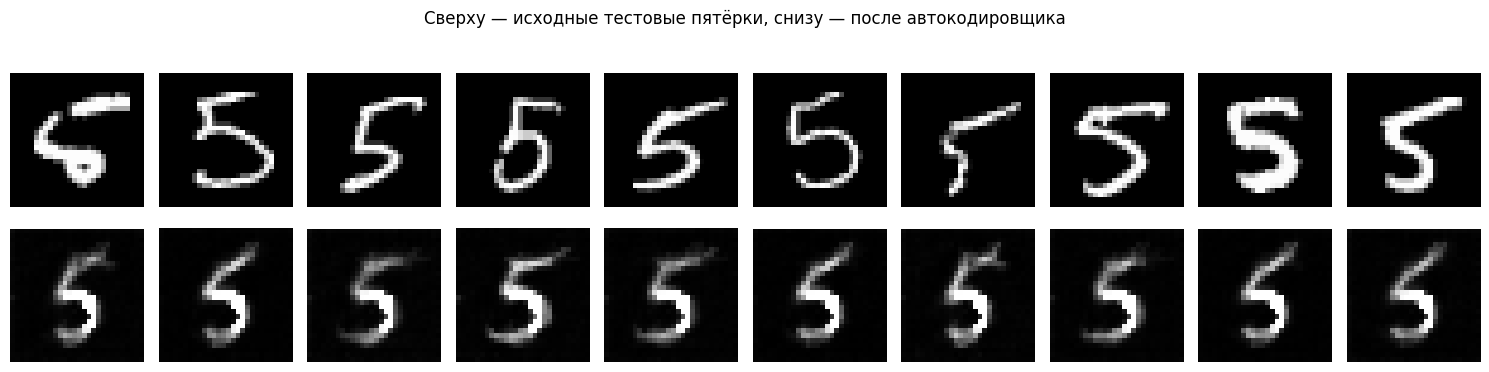

In [ ]:
# 6. Прогоняем тестовые пятёрки через автокодировщик и сравниваем.
n_show = 10
test_samples = X_test[:n_show]
predicted = autoencoder.predict(test_samples)

plt.figure(figsize=(15, 4))
for i in range(n_show):
    # Исходные пятёрки
    plt.subplot(2, n_show, i + 1)
    plt.imshow(test_samples[i].squeeze(), cmap='gray')
    plt.axis('off')
    if i == 0:
        plt.ylabel('Исходные', fontsize=10)

    # Облагороженные пятёрки
    plt.subplot(2, n_show, n_show + i + 1)
    plt.imshow(predicted[i].squeeze(), cmap='gray')
    plt.axis('off')
    if i == 0:
        plt.ylabel('После AE', fontsize=10)

plt.suptitle('Сверху — исходные тестовые пятёрки, снизу — после автокодировщика')
plt.tight_layout()
plt.show()